In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [1]:
# 라이브러리 Import
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("="*60)

라이브러리 로드 완료!


In [2]:
df1 = pd.read_csv('product_type_1.csv',header=[0,1])

In [3]:
df1

process                                                     \
           id product_type shot velocity_1 velocity_2 velocity_3   
0           1            1    1      0.144      0.170      0.188   
1        1002            1    2      0.144      0.170      0.182   
2        2003            1    3      0.144      0.170      0.182   
3        3004            1    4      0.144      0.170      0.182   
4        4005            1    5      0.144      0.172      0.176   
...       ...          ...  ...        ...        ...        ...   
2648  4197741            1  741      0.168      0.210      0.220   
2649  4199742            1  742      0.168      0.212      0.234   
2650  4201743            1  743      0.166      0.210      0.222   
2651  4203744            1  744      0.174      0.210      0.227   
2652  4205745            1  745      0.176      0.206      0.230   

                                                                        \
     high_velocity cylinder_pressure rapid_rise_time biscuit_thickness   
0            2.134               214           0.008                10   
1            2.124               217           0.008                11   
2            2.116               214           0.008                11   
3            2.137               217           0.008                11   
4            2.111               217           0.008                12   
...            ...               ...             ...               ...   
2648         2.217               239           0.009                12   
2649         2.238               239           0.010                13   
2650         2.277               239           0.008                12   
2651         2.260               239           0.010                12   
2652         2.254               239           0.007                12   

                                                                               \
     clamping_force cycle_time pressure_rise_time casting_pressure spray_time   
0               258       20.7              0.044             1037        7.8   
1               257       20.7              0.044             1052        7.8   
2               257       20.8              0.041             1037        7.8   
3               257       20.7              0.043             1051        7.8   
4               257       20.7              0.042             1052        7.8   
...             ...        ...                ...              ...        ...   
2648            257       21.0              0.044             1156        7.2   
2649            257       20.8              0.043             1156        7.1   
2650            255       20.7              0.044             1156        7.0   
2651            257       20.7              0.043             1157        7.1   
2652            257       20.8              0.043             1156        7.1   

                                             sensor               \
     spray_1_time spray_2_time melting_furnace_temp air_pressure   
0             0.7          0.8                695.0          6.3   
1             0.7          0.8                696.4          6.3   
2             0.7          0.8                696.4          6.3   
3             0.7          0.8                696.4          6.3   
4             0.7          0.8                697.9          6.4   
...           ...          ...                  ...          ...   
2648          1.2          0.7                680.4          6.8   
2649          1.0          0.7                679.1          7.0   
2650          1.0          0.7                679.1          7.0   
2651          1.0          0.7                679.1          7.0   
2652          1.0          0.7                678.0          6.8   

                                                                      \
     air_pressure_min air_pressure_max coolant_temp coolant_temp_min   
0                   3                9         26.0               10   
1  

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (process, id)                   2653 non-null   int64  
 1   (process, product_type)         2653 non-null   int64  
 2   (process, shot)                 2653 non-null   int64  
 3   (process, velocity_1)           2653 non-null   float64
 4   (process, velocity_2)           2653 non-null   float64
 5   (process, velocity_3)           2653 non-null   float64
 6   (process, high_velocity)        2653 non-null   float64
 7   (process, cylinder_pressure)    2653 non-null   int64  
 8   (process, rapid_rise_time)      2653 non-null   float64
 9   (process, biscuit_thickness)    2653 non-null   int64  
 10  (process, clamping_force)       2653 non-null   int64  
 11  (process, cycle_time)           2653 non-null   float64
 12  (process, pressure_rise_time)   2653 non-null

In [5]:
# 2) 간단한 EDA
print("\n결측치:\n", df1.isnull().sum().sort_values(ascending=False).head(10)) 
print("\n타겟 비율:\n", df1[('defect_flag', 'is_defect')].value_counts(normalize=True))


결측치:
 process  id                   0
         product_type         0
         shot                 0
         velocity_1           0
         velocity_2           0
         velocity_3           0
         high_velocity        0
         cylinder_pressure    0
         rapid_rise_time      0
         biscuit_thickness    0
dtype: int64

타겟 비율:
 (defect_flag, is_defect)
0    0.782887
1    0.217113
Name: proportion, dtype: float64


In [ ]:
# y: 불량 여부(0/1)
y = df1[('defect_flag', 'is_defect')].astype(int)

 # # y: Defects 그룹 전체 (멀티라벨)
# y_cols = [c for c in df.columns if c[0] == 'Defects']
# y = df[y_cols].astype(int)

X = df1[['process','sensor']].copy()
X = X.drop(columns=[('process','id'), ('process','product_type')])
X


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
print("train:", X_train.shape)
print("test:", X_test.shape)

print("train 불량률:", y_train.mean())
print("test 불량률:", y_test.mean())

train: (2122, 29)
test: (531, 29)
train 불량률: 0.2172478793590952
test 불량률: 0.21657250470809794


In [9]:
X_train.isnull().sum()

process  shot                    0
         velocity_1              0
         velocity_2              0
         velocity_3              0
         high_velocity           0
         cylinder_pressure       0
         rapid_rise_time         0
         biscuit_thickness       0
         clamping_force          0
         cycle_time              0
         pressure_rise_time      0
         casting_pressure        0
         spray_time              0
         spray_1_time            0
         spray_2_time            0
sensor   melting_furnace_temp    0
         air_pressure            0
         air_pressure_min        0
         air_pressure_max        0
         coolant_temp            0
         coolant_temp_min        0
         coolant_temp_max        0
         coolant_pressure        0
         factory_temp            0
         factory_temp_min        0
         factory_temp_max        0
         factory_humidity        0
         factory_humidity_min    0
         factory_hum

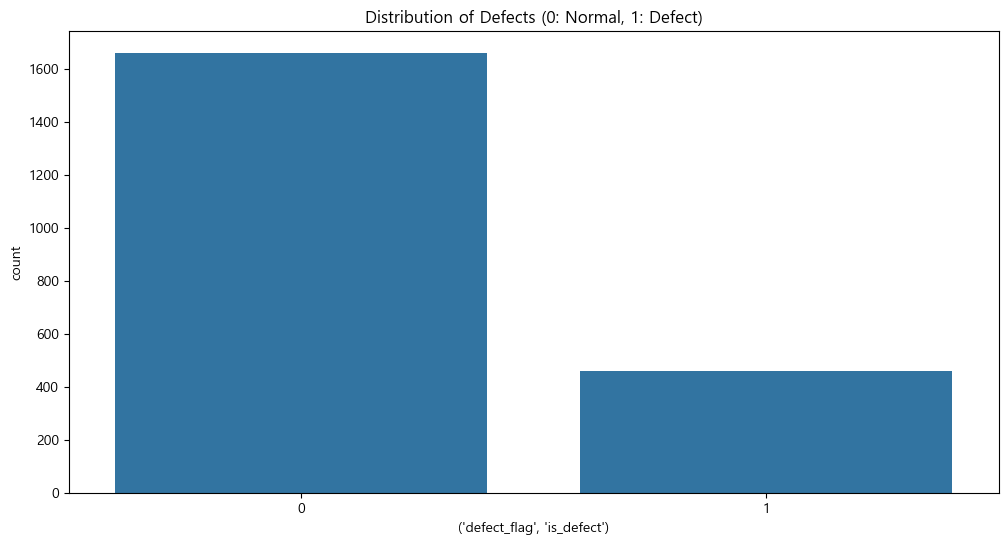

In [10]:
# y_train의 분포 확인
sns.countplot(x=y_train)
plt.title('Distribution of Defects (0: Normal, 1: Defect)')
plt.show()

In [14]:
X_train['process','shot'].value_counts()

(process, shot)
138     3
128     3
192     3
220     3
673     3
       ..
1128    1
858     1
1131    1
1149    1
992     1
Name: count, Length: 1187, dtype: int64

In [18]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 2122 entries, 528 to 1791
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (process, shot)                 2122 non-null   int64  
 1   (process, velocity_1)           2122 non-null   float64
 2   (process, velocity_2)           2122 non-null   float64
 3   (process, velocity_3)           2122 non-null   float64
 4   (process, high_velocity)        2122 non-null   float64
 5   (process, cylinder_pressure)    2122 non-null   int64  
 6   (process, rapid_rise_time)      2122 non-null   float64
 7   (process, biscuit_thickness)    2122 non-null   int64  
 8   (process, clamping_force)       2122 non-null   int64  
 9   (process, cycle_time)           2122 non-null   float64
 10  (process, pressure_rise_time)   2122 non-null   float64
 11  (process, casting_pressure)     2122 non-null   int64  
 12  (process, spray_time)           2122 non-null   

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Ratio (%)
6,"(process, rapid_rise_time)",0.008,0.008,0.000,0.0080,0.0080,780,36.76
14,"(process, spray_2_time)",0.800,0.800,0.000,0.8000,0.8000,324,15.27
5,"(process, cylinder_pressure)",215.000,218.000,3.000,210.5000,222.5000,271,12.77
11,"(process, casting_pressure)",1039.000,1054.000,15.000,1016.5000,1076.5000,271,12.77
12,"(process, spray_time)",7.900,8.300,0.400,7.3000,8.9000,245,11.55
9,"(process, cycle_time)",20.700,21.100,0.400,20.1000,21.7000,243,11.45
10,"(process, pressure_rise_time)",0.041,0.044,0.003,0.0365,0.0485,217,10.23
7,"(process, biscuit_thickness)",11.000,12.000,1.000,9.5000,13.5000,157,7.40
1,"(process, velocity_1)",0.142,0.144,0.002,0.1390,0.1470,111,5.23
2,"(process, velocity_2)",0.168,0.170,0.002,0.1650,0.1730,82,3.86


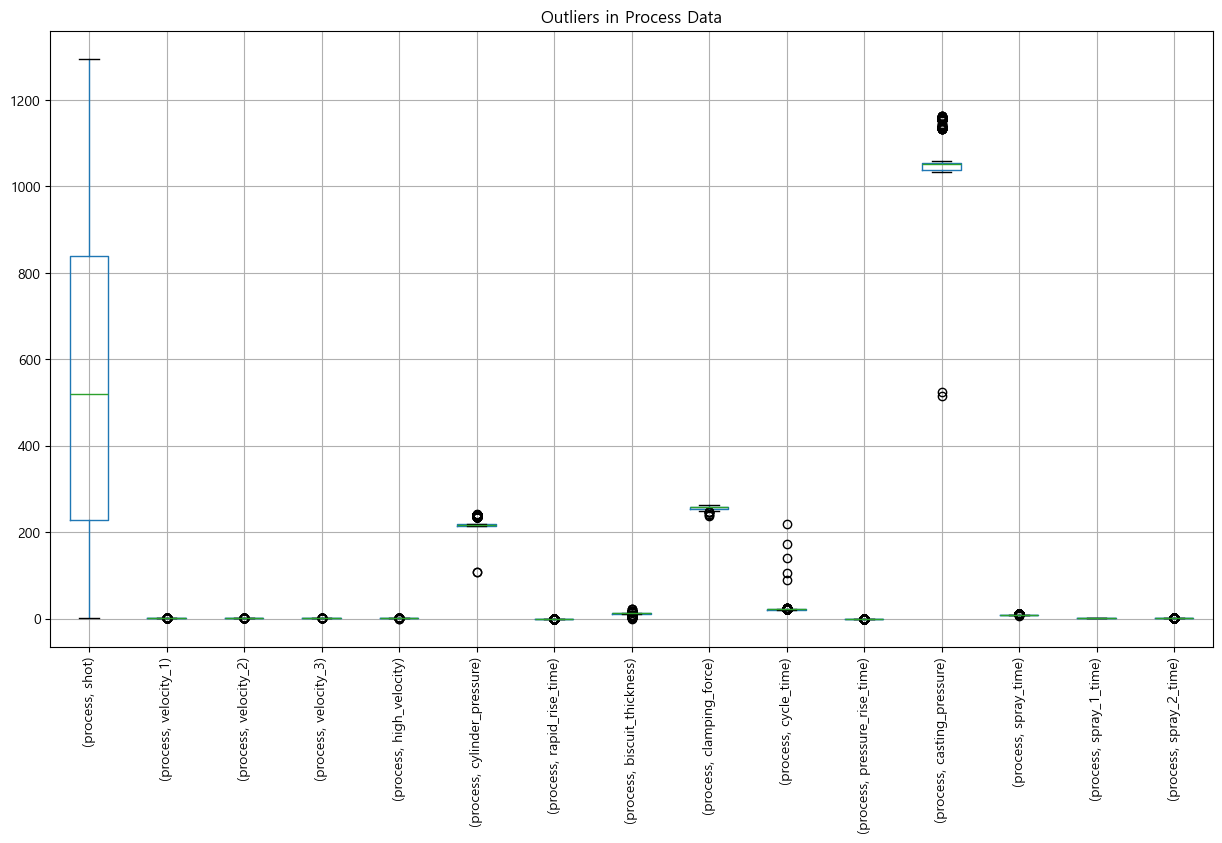

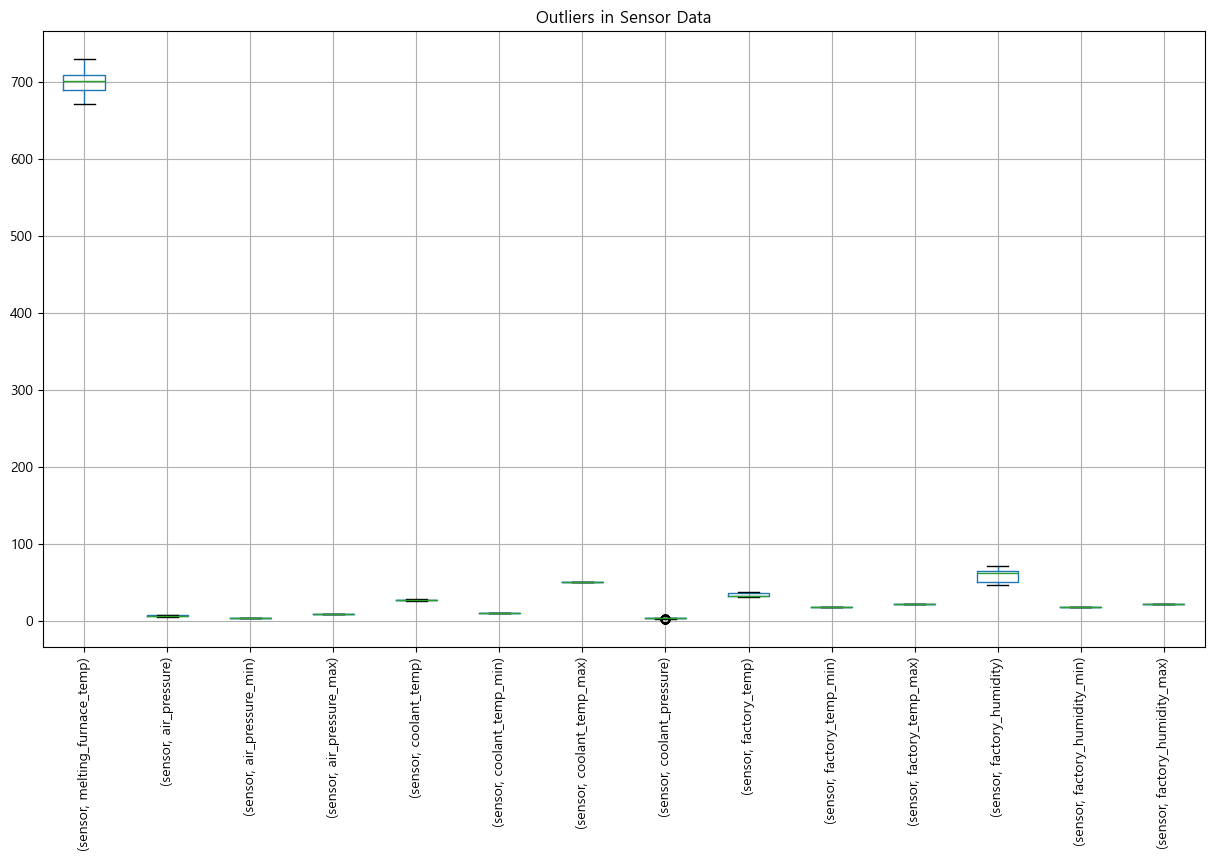

In [22]:
# IQR 기반 이상치 탐지 함수 정의
def get_outlier_stats(df):
    outlier_list = []
    
    for col in X_train.columns:
        # 숫자형 데이터만 처리
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = X_train[col].quantile(0.25)
            Q3 = X_train[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # 이상치 개수 계산
            outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
            outlier_count = len(outliers)
            outlier_ratio = (outlier_count / len(X_train)) * 100
            
            outlier_list.append({
                'Column': col,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'Lower Bound': lower_bound,
                'Upper Bound': upper_bound,
                'Outlier Count': outlier_count,
                'Outlier Ratio (%)': round(outlier_ratio, 2)
            })
            
    return pd.DataFrame(outlier_list)


outlier_summary = get_outlier_stats(X_train)

# 이상치가 많은 순서대로 정렬
display(outlier_summary.sort_values(by='Outlier Count', ascending=False))


# process 관련 주요 수치들의 분포 확인
process_cols = [col for col in X_train.columns if 'process' in str(col)]
plt.figure(figsize=(15, 8))
X_train[process_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Outliers in Process Data")
plt.show()


# sensor 관련 주요 수치들의 분포 확인
sensor_cols = [col for col in X_train.columns if 'sensor' in str(col)]
plt.figure(figsize=(15, 8))
X_train[sensor_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Outliers in Sensor Data")
plt.show()

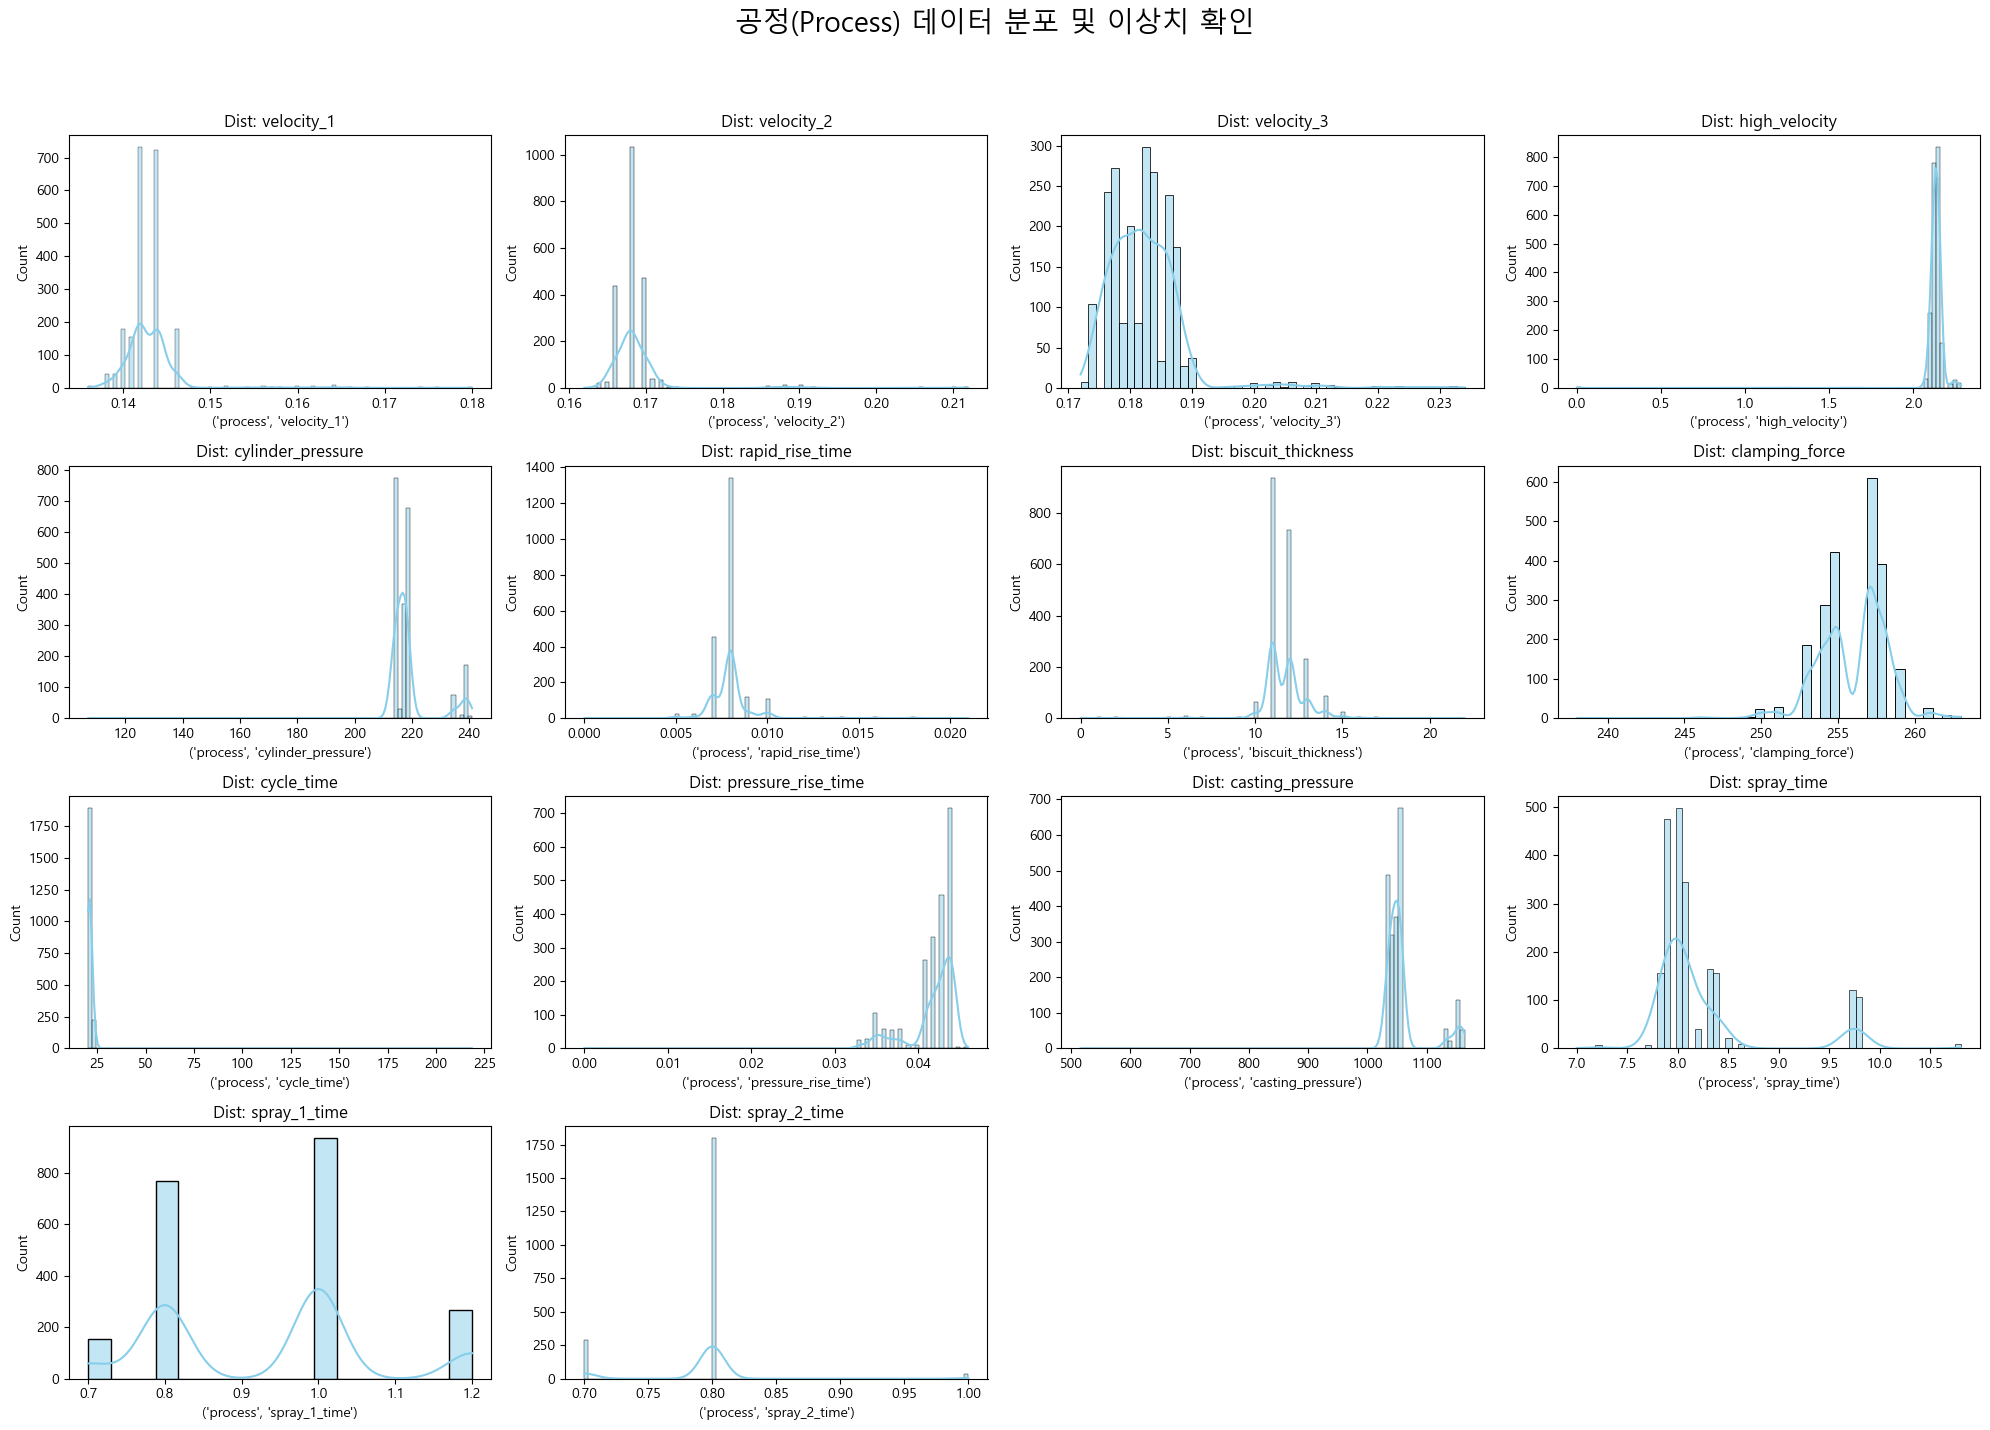

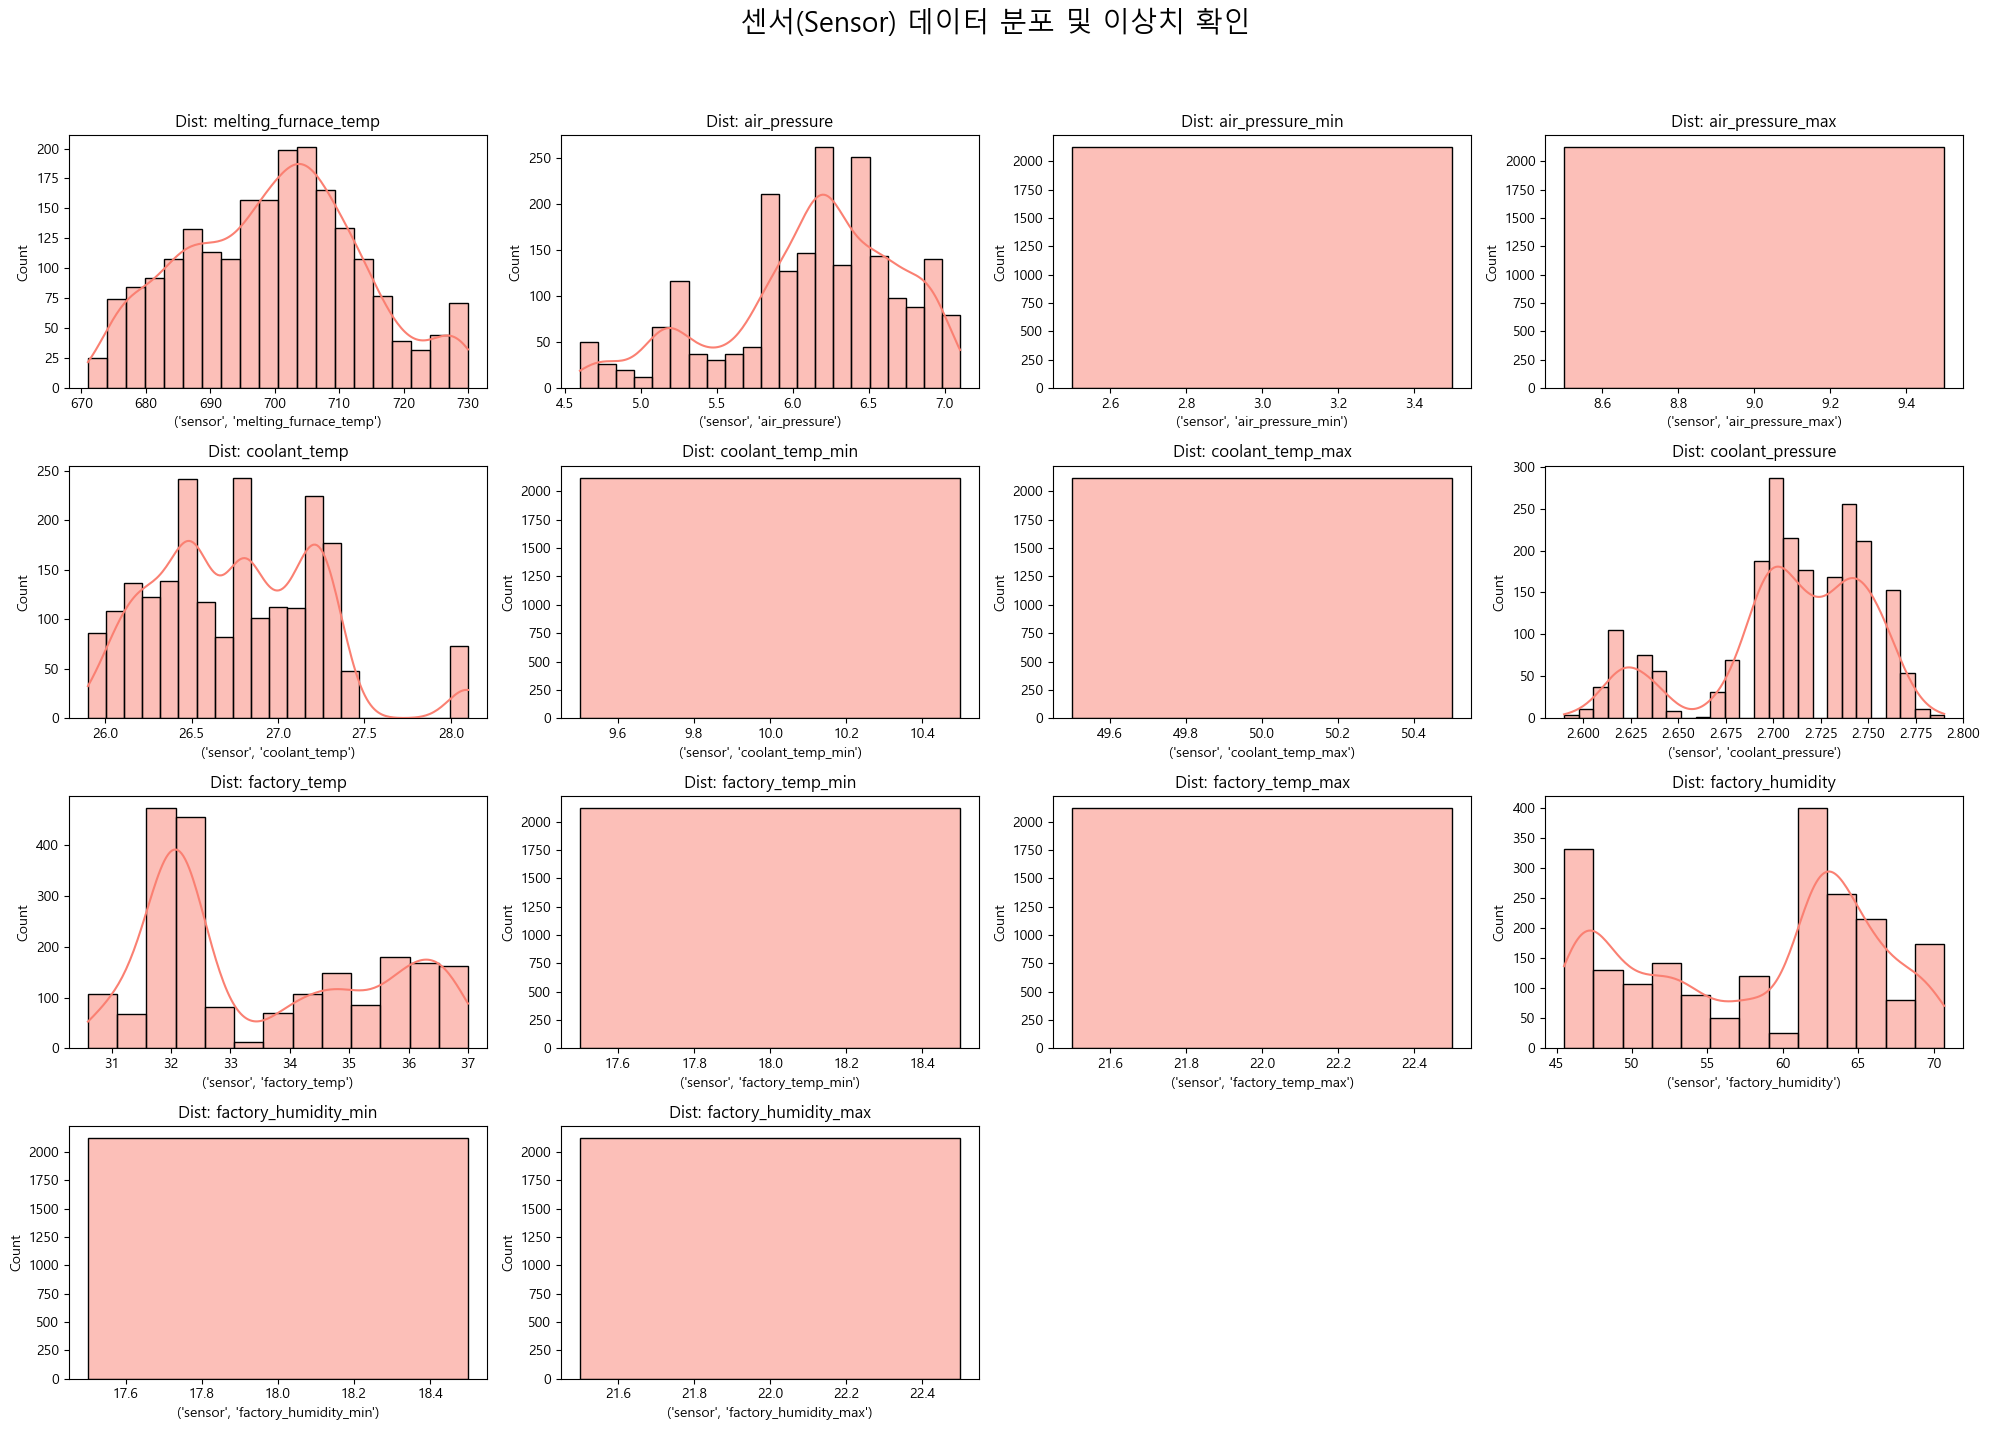

In [23]:
# Process 관련 컬럼 히스토그램
process_cols = [col for col in X_train.columns if 'process' in str(col) and 'shot' not in str(col)]

plt.figure(figsize=(20, 15))
plt.suptitle("공정(Process) 데이터 분포 및 이상치 확인", fontsize=20)

for i, col in enumerate(process_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X_train[col], kde=True, color='skyblue')
    plt.title(f'Dist: {col[1]}') # MultiIndex의 하위 컬럼명 사용
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

# Sensor 관련 컬럼 히스토그램
sensor_cols = [col for col in X_train.columns if 'sensor' in str(col)]

plt.figure(figsize=(20, 15))
plt.suptitle("센서(Sensor) 데이터 분포 및 이상치 확인", fontsize=20)

for i, col in enumerate(sensor_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X_train[col], kde=True, color='salmon')
    plt.title(f'Dist: {col[1]}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [29]:
defect_cols = [col for col in df1.columns if 'defect' in str(col)]

for col in defect_cols:
    print(f"--- [Column: {col}] ---")
    print(df1[col].value_counts())
    print("\n") 

# 각 컬럼의 value_counts를 데이터프레임 하나로 병합
counts_summary = df1[defect_cols].apply(lambda x: x.value_counts()).fillna(0).astype(int)
display(counts_summary)

--- [Column: ('defects', 'short_shot_1')] ---
(defects, short_shot_1)
0    2545
1     108
Name: count, dtype: int64


--- [Column: ('defects', 'bubble_1')] ---
(defects, bubble_1)
0    2593
1      60
Name: count, dtype: int64


--- [Column: ('defects', 'exfoliation_1')] ---
(defects, exfoliation_1)
0    2529
1     124
Name: count, dtype: int64


--- [Column: ('defects', 'blow_hole_1')] ---
(defects, blow_hole_1)
0    2653
Name: count, dtype: int64


--- [Column: ('defects', 'stain_1')] ---
(defects, stain_1)
0    2650
1       3
Name: count, dtype: int64


--- [Column: ('defects', 'dent_1')] ---
(defects, dent_1)
0    2650
1       3
Name: count, dtype: int64


--- [Column: ('defects', 'deformation_1')] ---
(defects, deformation_1)
0    2545
1     108
Name: count, dtype: int64


--- [Column: ('defects', 'contamination_1')] ---
(defects, contamination_1)
0    2653
Name: count, dtype: int64


--- [Column: ('defects', 'impurity_1')] ---
(defects, impurity_1)
0    2653
Name: count, dtype: in

defects                                                    \
  short_shot_1 bubble_1 exfoliation_1 blow_hole_1 stain_1 dent_1   
0         2545     2593          2529        2653    2650   2650   
1          108       60           124           0       3      3   

                                                                            \
  deformation_1 contamination_1 impurity_1 crack_1 scratch_1 buring_mark_1   
0          2545            2653       2653    2653      2653          2653   
1           108               0          0       0         0             0   

                                                                               \
  inclusions_1 short_shot_2 bubble_2 exfoliation_2 blow_hole_2 stain_2 dent_2   
0         2653         2593     2648          2567        2653    2653   2653   
1            0           60        5            86           0       0      0   

                                                                            \
  deformation_2 contamination_2 impurity_2 crack_2 scratch_2 buring_mark_2   
0          2589            2653       2653    2653      2653          2653   
1            64               0          0       0         0             0   

               defect_flag  
  inclusions_2   is_defect  
0         2653        2077  
1            0         576

In [36]:
# 값이 모두 0인 컬럼명 리스트 생성
only_zero_cols = [col for col in defect_cols if (df1[col] == 0).all()]

print(f"값이 0만 있는 컬럼들({len(only_zero_cols)}개): \n{only_zero_cols} ")

값이 0만 있는 컬럼들(16개): 
[('defects', 'blow_hole_1'), ('defects', 'contamination_1'), ('defects', 'impurity_1'), ('defects', 'crack_1'), ('defects', 'scratch_1'), ('defects', 'buring_mark_1'), ('defects', 'inclusions_1'), ('defects', 'blow_hole_2'), ('defects', 'stain_2'), ('defects', 'dent_2'), ('defects', 'contamination_2'), ('defects', 'impurity_2'), ('defects', 'crack_2'), ('defects', 'scratch_2'), ('defects', 'buring_mark_2'), ('defects', 'inclusions_2')] 


In [35]:
d = df1.copy()
d_reduced = d.drop(columns=only_zero_cols)

d_reduced

process                                                     \
           id product_type shot velocity_1 velocity_2 velocity_3   
0           1            1    1      0.144      0.170      0.188   
1        1002            1    2      0.144      0.170      0.182   
2        2003            1    3      0.144      0.170      0.182   
3        3004            1    4      0.144      0.170      0.182   
4        4005            1    5      0.144      0.172      0.176   
...       ...          ...  ...        ...        ...        ...   
2648  4197741            1  741      0.168      0.210      0.220   
2649  4199742            1  742      0.168      0.212      0.234   
2650  4201743            1  743      0.166      0.210      0.222   
2651  4203744            1  744      0.174      0.210      0.227   
2652  4205745            1  745      0.176      0.206      0.230   

                                                                        \
     high_velocity cylinder_pressure rapid_rise_time biscuit_thickness   
0            2.134               214           0.008                10   
1            2.124               217           0.008                11   
2            2.116               214           0.008                11   
3            2.137               217           0.008                11   
4            2.111               217           0.008                12   
...            ...               ...             ...               ...   
2648         2.217               239           0.009                12   
2649         2.238               239           0.010                13   
2650         2.277               239           0.008                12   
2651         2.260               239           0.010                12   
2652         2.254               239           0.007                12   

                                                                               \
     clamping_force cycle_time pressure_rise_time casting_pressure spray_time   
0               258       20.7              0.044             1037        7.8   
1               257       20.7              0.044             1052        7.8   
2               257       20.8              0.041             1037        7.8   
3               257       20.7              0.043             1051        7.8   
4               257       20.7              0.042             1052        7.8   
...             ...        ...                ...              ...        ...   
2648            257       21.0              0.044             1156        7.2   
2649            257       20.8              0.043             1156        7.1   
2650            255       20.7              0.044             1156        7.0   
2651            257       20.7              0.043             1157        7.1   
2652            257       20.8              0.043             1156        7.1   

                                             sensor               \
     spray_1_time spray_2_time melting_furnace_temp air_pressure   
0             0.7          0.8                695.0          6.3   
1             0.7          0.8                696.4          6.3   
2             0.7          0.8                696.4          6.3   
3             0.7          0.8                696.4          6.3   
4             0.7          0.8                697.9          6.4   
...           ...          ...                  ...          ...   
2648          1.2          0.7                680.4          6.8   
2649          1.0          0.7                679.1          7.0   
2650          1.0          0.7                679.1          7.0   
2651          1.0          0.7                679.1          7.0   
2652          1.0          0.7                678.0          6.8   

                                                                      \
     air_pressure_min air_pressure_max coolant_temp coolant_temp_min   
0                   3                9         26.0               10   
1  

In [38]:
defect_cols = [col for col in d_reduced.columns if 'defect' in str(col)]

# 값이 모두 0인 컬럼명 리스트 생성
only_zero_cols = [col for col in defect_cols if (d_reduced[col] == 0).all()]

print(f"값이 0만 있는 컬럼들({len(only_zero_cols)}개): \n{only_zero_cols} ")

값이 0만 있는 컬럼들(0개): 
[] 


In [39]:
df2 = pd.read_csv('product_type_2.csv',header=[0,1])

In [40]:
defect_cols = [col for col in df2.columns if 'defect' in str(col)]

for col in defect_cols:
    print(f"--- [Column: {col}] ---")
    print(df2[col].value_counts())
    print("\n") 

# 각 컬럼의 value_counts를 데이터프레임 하나로 병합
counts_summary = df2[defect_cols].apply(lambda x: x.value_counts()).fillna(0).astype(int)
display(counts_summary)

--- [Column: ('defects', 'short_shot_1')] ---
(defects, short_shot_1)
0    1788
1     176
Name: count, dtype: int64


--- [Column: ('defects', 'bubble_1')] ---
(defects, bubble_1)
0    1963
1       1
Name: count, dtype: int64


--- [Column: ('defects', 'exfoliation_1')] ---
(defects, exfoliation_1)
0    1964
Name: count, dtype: int64


--- [Column: ('defects', 'blow_hole_1')] ---
(defects, blow_hole_1)
0    1852
1     112
Name: count, dtype: int64


--- [Column: ('defects', 'stain_1')] ---
(defects, stain_1)
0    1871
1      93
Name: count, dtype: int64


--- [Column: ('defects', 'dent_1')] ---
(defects, dent_1)
0    1960
1       4
Name: count, dtype: int64


--- [Column: ('defects', 'deformation_1')] ---
(defects, deformation_1)
0    1964
Name: count, dtype: int64


--- [Column: ('defects', 'contamination_1')] ---
(defects, contamination_1)
0    1960
1       4
Name: count, dtype: int64


--- [Column: ('defects', 'impurity_1')] ---
(defects, impurity_1)
0    1962
1       2
Name: count,

defects                                                    \
  short_shot_1 bubble_1 exfoliation_1 blow_hole_1 stain_1 dent_1   
0         1788     1963          1964        1852    1871   1960   
1          176        1             0         112      93      4   

                                                                            \
  deformation_1 contamination_1 impurity_1 crack_1 scratch_1 buring_mark_1   
0          1964            1960       1962    1963      1962          1959   
1             0               4          2       1         2             5   

                                                                               \
  inclusions_1 short_shot_2 bubble_2 exfoliation_2 blow_hole_2 stain_2 dent_2   
0         1964         1916     1964          1964        1885    1964   1960   
1            0           48        0             0          79       0      4   

                                                                            \
  deformation_2 contamination_2 impurity_2 crack_2 scratch_2 buring_mark_2   
0          1964            1956       1959    1962      1964          1964   
1             0               8          5       2         0             0   

               defect_flag  
  inclusions_2   is_defect  
0         1963        1467  
1            1         497

In [42]:
# 값이 모두 0인 컬럼명 리스트 생성
only_zero_cols = [col for col in defect_cols if (df2[col] == 0).all()]

print(f"값이 0만 있는 컬럼들({len(only_zero_cols)}개): \n{only_zero_cols} ")

값이 0만 있는 컬럼들(9개): 
[('defects', 'exfoliation_1'), ('defects', 'deformation_1'), ('defects', 'inclusions_1'), ('defects', 'bubble_2'), ('defects', 'exfoliation_2'), ('defects', 'stain_2'), ('defects', 'deformation_2'), ('defects', 'scratch_2'), ('defects', 'buring_mark_2')] 


In [43]:
dd = df2.copy()
d_reduced = dd.drop(columns=only_zero_cols)

d_reduced

process                                                     \
           id product_type shot velocity_1 velocity_2 velocity_3   
0     4207011            2   11      0.156      0.166      0.192   
1     4208012            2   12      0.157      0.166      0.204   
2     4209013            2   13      0.156      0.170      0.204   
3     4210014            2   14      0.154      0.170      0.202   
4     4211015            2   15      0.146      0.160      0.198   
...       ...          ...  ...        ...        ...        ...   
1959  7525657            2  657      0.144      0.173      0.200   
1960  7527658            2  658      0.144      0.173      0.200   
1961  7529659            2  659      0.150      0.166      0.210   
1962  7531660            2  660      0.144      0.174      0.206   
1963  7533661            2  661      0.147      0.174      0.204   

                                                                        \
     high_velocity cylinder_pressure rapid_rise_time biscuit_thickness   
0            2.723               265           0.012                20   
1            2.730               264           0.014                19   
2            2.715               265           0.012                18   
3            2.717               264           0.011                20   
4            2.684               264           0.012                20   
...            ...               ...             ...               ...   
1959         2.536               264           0.012                17   
1960         2.536               264           0.012                17   
1961         2.492               265           0.011                17   
1962         2.514               264           0.011                16   
1963         2.532               265           0.012                18   

                                                                               \
     clamping_force cycle_time pressure_rise_time casting_pressure spray_time   
0               357       36.6              0.041              595       12.5   
1               359       36.5              0.040              594       12.5   
2               361       36.5              0.041              595       12.5   
3               364       36.5              0.042              595       12.5   
4               357       36.5              0.042              595       12.5   
...             ...        ...                ...              ...        ...   
1959            381       36.3              0.036              595       12.1   
1960            381       36.3              0.036              595       12.1   
1961            381       36.2              0.033              595       12.1   
1962            381       36.2              0.041              595       12.1   
1963            382       36.2              0.036              596       12.1   

                                             sensor               \
     spray_1_time spray_2_time melting_furnace_temp air_pressure   
0             2.0          2.2                671.6          6.5   
1             2.0          2.2                672.1          6.4   
2             2.0          2.2                672.4          6.4   
3             2.0          2.2                672.4          6.4   
4             2.0          2.2                672.4          6.3   
...           ...          ...                  ...          ...   
1959          2.0          2.0                666.8          6.7   
1960          2.0          2.0                667.4          6.7   
1961          2.0          2.0                667.4          6.7   
1962          2.0          2.0                667.8          7.0   
1963          2.0          2.0                668.5          6.8   

                                                                      \
     air_pressure_min air_pressure_max coolant_temp coolant_temp_min   
0                   3                9         26.1               10   
1  

In [44]:
defect_cols = [col for col in d_reduced.columns if 'defect' in str(col)]

# 값이 모두 0인 컬럼명 리스트 생성
only_zero_cols = [col for col in defect_cols if (d_reduced[col] == 0).all()]

print(f"값이 0만 있는 컬럼들({len(only_zero_cols)}개): \n{only_zero_cols} ")

값이 0만 있는 컬럼들(0개): 
[] 
